In [2]:
import pandas as pd

matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

matches.head()

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
powerplay = deliveries[deliveries["over"] <= 6]

powerplay.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
top_powerplay_batters = (
    powerplay.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_powerplay_batters

KeyError: 'batsman'

In [5]:
print(deliveries.columns)


Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


In [6]:
top_powerplay_batters = (
    powerplay.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_powerplay_batters

batter
S Dhawan        3776
DA Warner       3648
V Kohli         3178
CH Gayle        2668
AM Rahane       2567
G Gambhir       2539
RG Sharma       2437
F du Plessis    2361
RV Uthappa      2353
KL Rahul        2260
Name: batsman_runs, dtype: int64

In [7]:
death_overs = deliveries[deliveries["over"] >= 16]

death_overs.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
100,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,1,BB McCullum,Z Khan,DJ Hussey,1,0,1,NaN,0,NaN,NaN,NaN
101,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,2,DJ Hussey,Z Khan,BB McCullum,2,0,2,NaN,0,NaN,NaN,NaN
102,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,3,DJ Hussey,Z Khan,BB McCullum,1,0,1,NaN,0,NaN,NaN,NaN
103,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,4,BB McCullum,Z Khan,DJ Hussey,6,0,6,NaN,0,NaN,NaN,NaN
104,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,16,5,BB McCullum,Z Khan,DJ Hussey,2,0,2,NaN,0,NaN,NaN,NaN


In [8]:
top_death_batters = (
    death_overs.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_death_batters

batter
MS Dhoni          2786
KA Pollard        1708
KD Karthik        1565
AB de Villiers    1421
RA Jadeja         1420
RG Sharma         1176
HH Pandya         1126
V Kohli           1099
AD Russell        1065
DA Miller          988
Name: batsman_runs, dtype: int64

NameError: name 'plt' is not defined

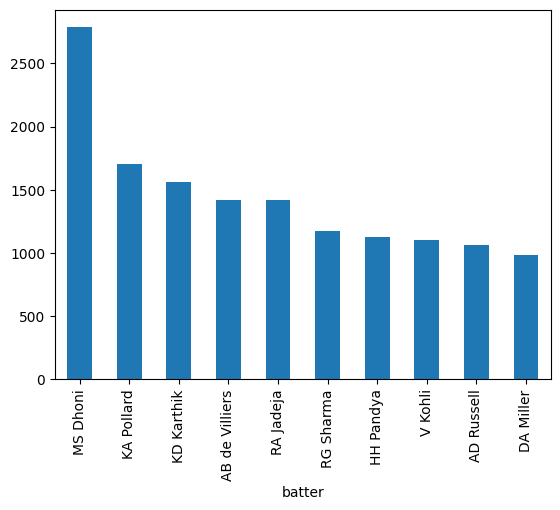

In [9]:
top_death_batters.plot(kind="bar")

plt.title("Top Death Over Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Runs")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

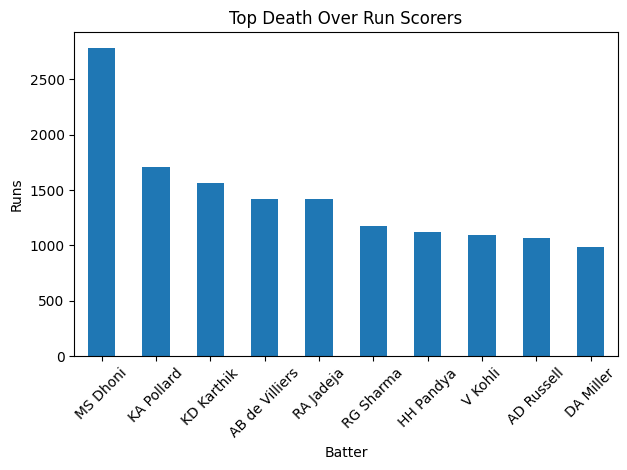

In [10]:
import matplotlib.pyplot as plt
top_death_batters.plot(kind="bar")

plt.title("Top Death Over Run Scorers")
plt.xlabel("Batter")
plt.ylabel("Runs")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
death_stats = death_overs.groupby("batter").agg({
    "batsman_runs": "sum",
    "ball": "count"
})

death_stats["strike_rate"] = (death_stats["batsman_runs"] / death_stats["ball"]) * 100

death_stats.sort_values(by="strike_rate", ascending=False).head(10)

,batsman_runs,ball,strike_rate
batter,,,
PA Reddy,6,2,300.000000
L Wood,9,3,300.000000
T Stubbs,233,85,274.117647
Misbah-ul-Haq,40,15,266.666667
B Stanlake,5,2,250.000000
Naman Dhir,49,20,245.000000
BJ Rohrer,73,31,235.483871
LPC Silva,23,10,230.000000
YBK Jaiswal,48,21,228.571429


In [12]:
death_stats = death_stats[death_stats["ball"] > 100]

death_stats.sort_values(by="strike_rate", ascending=False).head(10)

,batsman_runs,ball,strike_rate
batter,,,
AB de Villiers,1421,635,223.779528
LS Livingstone,204,103,198.058252
RR Pant,626,318,196.855346
CH Gayle,404,209,193.301435
V Kohli,1099,571,192.469352
JH Kallis,303,159,190.566038
H Klaasen,306,161,190.062112
F du Plessis,416,220,189.090909
RG Sharma,1176,625,188.160000


In [13]:
pp = powerplay.groupby("batter")["batsman_runs"].sum()
death = death_overs.groupby("batter")["batsman_runs"].sum()

comparison = pd.DataFrame({
    "powerplay_runs": pp,
    "death_runs": death
}).fillna(0)

comparison["total"] = comparison["powerplay_runs"] + comparison["death_runs"]

comparison.sort_values(by="total", ascending=False).head(10)

,powerplay_runs,death_runs,total
batter,,,
V Kohli,3178.0,1099.0,4277.0
S Dhawan,3776.0,499.0,4275.0
DA Warner,3648.0,415.0,4063.0
RG Sharma,2437.0,1176.0,3613.0
CH Gayle,2668.0,404.0,3072.0
AM Rahane,2567.0,386.0,2953.0
MS Dhoni,108.0,2786.0,2894.0
KL Rahul,2260.0,586.0,2846.0
F du Plessis,2361.0,416.0,2777.0


In [14]:
comparison["difference"] = comparison["powerplay_runs"] - comparison["death_runs"]

comparison.sort_values(by="difference", ascending=False).head(10)

,powerplay_runs,death_runs,total,difference
batter,,,,
S Dhawan,3776.0,499.0,4275.0,3277.0
DA Warner,3648.0,415.0,4063.0,3233.0
G Gambhir,2539.0,172.0,2711.0,2367.0
CH Gayle,2668.0,404.0,3072.0,2264.0
AM Rahane,2567.0,386.0,2953.0,2181.0
V Kohli,3178.0,1099.0,4277.0,2079.0
PA Patel,2058.0,63.0,2121.0,1995.0
F du Plessis,2361.0,416.0,2777.0,1945.0
RV Uthappa,2353.0,415.0,2768.0,1938.0


In [15]:
comparison.sort_values(by="difference").head(10)

,powerplay_runs,death_runs,total,difference
batter,,,,
MS Dhoni,108.0,2786.0,2894.0,-2678.0
KA Pollard,82.0,1708.0,1790.0,-1626.0
RA Jadeja,92.0,1420.0,1512.0,-1328.0
AD Russell,56.0,1065.0,1121.0,-1009.0
KD Karthik,582.0,1565.0,2147.0,-983.0
HH Pandya,238.0,1126.0,1364.0,-888.0
DA Miller,161.0,988.0,1149.0,-827.0
AR Patel,79.0,760.0,839.0,-681.0
DJ Bravo,149.0,800.0,949.0,-651.0


In [2]:
import pandas as pd

deliveries = pd.read_csv("../data/deliveries.csv")
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
import pandas as pd
deliveries = pd.read_csv("../data/deliveries.csv")
middle = deliveries[(deliveries["over"] > 6) & (deliveries["over"] < 16)]
middle.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
44,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,1,BB McCullum,Z Khan,RT Ponting,0,0,0,NaN,0,NaN,NaN,NaN
45,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,2,BB McCullum,Z Khan,RT Ponting,1,0,1,NaN,0,NaN,NaN,NaN
46,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,3,RT Ponting,Z Khan,BB McCullum,1,0,1,NaN,0,NaN,NaN,NaN
47,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,4,BB McCullum,Z Khan,RT Ponting,1,0,1,NaN,0,NaN,NaN,NaN
48,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,5,RT Ponting,Z Khan,BB McCullum,1,0,1,NaN,0,NaN,NaN,NaN


In [5]:
top_middle_batters = (
    middle.groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_middle_batters

batter
V Kohli           3737
RG Sharma         3017
SK Raina          2999
AB de Villiers    2808
KD Karthik        2696
AT Rayudu         2510
DA Warner         2504
S Dhawan          2494
MS Dhoni          2349
SV Samson         2335
Name: batsman_runs, dtype: int64

In [8]:
pp_bowl = deliveries[deliveries["over"] <= 6]

pp_underrated = pp_bowl.groupby("bowler").agg({
    "total_runs": "sum",
    "ball": "count",
    "is_wicket": "sum"
})

pp_underrated["economy"] = (pp_underrated["total_runs"] / pp_underrated["ball"]) * 6
pp_underrated["strike_rate"] = pp_underrated["ball"] / pp_underrated["is_wicket"]

pp_underrated = pp_underrated[pp_underrated["ball"] > 100]

pp_underrated.sort_values("economy").head(10)

,total_runs,ball,is_wicket,economy,strike_rate
bowler,,,,,
SMSM Senanayake,111,129,4,5.162791,32.250000
A Kumble,190,212,5,5.377358,42.400000
JC Archer,393,413,17,5.709443,24.294118
Ankit Sharma,164,170,7,5.788235,24.285714
A Chandila,168,174,10,5.793103,17.400000
GD McGrath,227,232,9,5.870690,25.777778
DL Vettori,142,145,5,5.875862,29.000000
M Muralitharan,297,297,5,6.000000,59.400000
Sohail Tanvir,152,152,6,6.000000,25.333333


In [9]:
pp_elite = pp_bowl.groupby("bowler").agg({
    "total_runs": "sum",
    "ball": "count",
    "is_wicket": "sum"
})

pp_elite["economy"] = (pp_elite["total_runs"] / pp_elite["ball"]) * 6
pp_elite["strike_rate"] = pp_elite["ball"] / pp_elite["is_wicket"]

pp_elite = pp_elite[pp_elite["ball"] > 500]

pp_elite.sort_values("economy").head(10)

,total_runs,ball,is_wicket,economy,strike_rate
bowler,,,,,
DW Steyn,1247,1220,37,6.132787,32.972973
SL Malinga,1225,1182,41,6.218274,28.829268
B Kumar,2372,2242,77,6.347904,29.116883
JJ Bumrah,1247,1151,40,6.500434,28.775000
R Ashwin,1652,1523,55,6.508207,27.690909
SP Narine,1321,1204,30,6.583056,40.133333
P Kumar,1892,1724,48,6.584687,35.916667
Z Khan,1502,1364,59,6.607038,23.118644
Harbhajan Singh,1184,1069,46,6.645463,23.239130


In [15]:
pp_elite["impact_score"] = pp_elite["economy"] * pp_elite["strike_rate"]
pp_elite.sort_values("impact_score").head(10)
pp_elite.sort_values("is_wicket", ascending=False).head(10)



,total_runs,ball,is_wicket,economy,strike_rate,impact_score,wickets_per_over
bowler,,,,,,,
B Kumar,2372,2242,77,6.347904,29.116883,184.831169,0.206066
Sandeep Sharma,1948,1705,66,6.855132,25.833333,177.090909,0.232258
TA Boult,1728,1484,63,6.986523,23.555556,164.571429,0.254717
UT Yadav,2067,1624,63,7.636700,25.777778,196.857143,0.232759
I Sharma,1885,1582,62,7.149178,25.516129,182.419355,0.235145
DL Chahar,1783,1410,61,7.587234,23.114754,175.377049,0.259574
Z Khan,1502,1364,59,6.607038,23.118644,152.745763,0.259531
R Ashwin,1652,1523,55,6.508207,27.690909,180.218182,0.216678
Mohammed Shami,1741,1420,51,7.356338,27.843137,204.823529,0.215493


In [16]:
pp_elite.sort_values("is_wicket", ascending=False).head(10)

,total_runs,ball,is_wicket,economy,strike_rate,impact_score,wickets_per_over
bowler,,,,,,,
B Kumar,2372,2242,77,6.347904,29.116883,184.831169,0.206066
Sandeep Sharma,1948,1705,66,6.855132,25.833333,177.090909,0.232258
TA Boult,1728,1484,63,6.986523,23.555556,164.571429,0.254717
UT Yadav,2067,1624,63,7.636700,25.777778,196.857143,0.232759
I Sharma,1885,1582,62,7.149178,25.516129,182.419355,0.235145
DL Chahar,1783,1410,61,7.587234,23.114754,175.377049,0.259574
Z Khan,1502,1364,59,6.607038,23.118644,152.745763,0.259531
R Ashwin,1652,1523,55,6.508207,27.690909,180.218182,0.216678
Mohammed Shami,1741,1420,51,7.356338,27.843137,204.823529,0.215493


In [17]:
pp_elite.sort_values("wickets_per_over", ascending=False).head(10)

,total_runs,ball,is_wicket,economy,strike_rate,impact_score,wickets_per_over
bowler,,,,,,,
Rashid Khan,612,509,25,7.214145,20.360000,146.880000,0.294695
YS Chahal,931,751,35,7.438083,21.457143,159.600000,0.279627
AD Russell,710,524,24,8.129771,21.833333,177.500000,0.274809
MJ McClenaghan,900,703,32,7.681366,21.968750,168.750000,0.273115
S Sreesanth,750,642,29,7.009346,22.137931,155.172414,0.271028
MM Patel,857,761,34,6.756899,22.382353,151.235294,0.268068
MM Sharma,1237,942,42,7.878981,22.428571,176.714286,0.267516
K Rabada,1115,833,37,8.031212,22.513514,180.810811,0.266507
DL Chahar,1783,1410,61,7.587234,23.114754,175.377049,0.259574


In [18]:
pp_elite["combined_score"] = (
    pp_elite["economy"] * 0.5 +
    pp_elite["strike_rate"] * 0.3 +
    (1 / pp_elite["wickets_per_over"]) * 0.2
)

pp_elite.sort_values("combined_score").head(10)

,total_runs,ball,is_wicket,economy,strike_rate,impact_score,wickets_per_over,combined_score
bowler,,,,,,,,
Rashid Khan,612,509,25,7.214145,20.360000,146.880000,0.294695,10.393739
MM Patel,857,761,34,6.756899,22.382353,151.235294,0.268068,10.839234
YS Chahal,931,751,35,7.438083,21.457143,159.600000,0.279627,10.871422
S Sreesanth,750,642,29,7.009346,22.137931,155.172414,0.271028,10.883983
Z Khan,1502,1364,59,6.607038,23.118644,152.745763,0.259531,11.009734
Harbhajan Singh,1184,1069,46,6.645463,23.239130,154.434783,0.258185,11.069108
MJ McClenaghan,900,703,32,7.681366,21.968750,168.750000,0.273115,11.163599
AD Russell,710,524,24,8.129771,21.833333,177.500000,0.274809,11.342663
TA Boult,1728,1484,63,6.986523,23.555556,164.571429,0.254717,11.345113


In [20]:
print("Bhuvneshwar Kumar:\n", pp_elite.loc["B Kumar"], "\n")
print("Sandeep Sharma:\n", pp_elite.loc["Sandeep Sharma"], "\n")
print("Trent Boult:\n", pp_elite.loc["TA Boult"])

Bhuvneshwar Kumar:
 total_runs          2372.000000
ball                2242.000000
is_wicket             77.000000
economy                6.347904
strike_rate           29.116883
impact_score         184.831169
wickets_per_over       0.206066
combined_score        12.879580
Name: B Kumar, dtype: float64 

Sandeep Sharma:
 total_runs          1948.000000
ball                1705.000000
is_wicket             66.000000
economy                6.855132
strike_rate           25.833333
impact_score         177.090909
wickets_per_over       0.232258
combined_score        12.038677
Name: Sandeep Sharma, dtype: float64 

Trent Boult:
 total_runs          1728.000000
ball                1484.000000
is_wicket             63.000000
economy                6.986523
strike_rate           23.555556
impact_score         164.571429
wickets_per_over       0.254717
combined_score        11.345113
Name: TA Boult, dtype: float64


In [21]:
mid_bowl = deliveries[(deliveries["over"] > 6) & (deliveries["over"] < 16)]
mid_bowl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
44,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,1,BB McCullum,Z Khan,RT Ponting,0,0,0,NaN,0,NaN,NaN,NaN
45,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,2,BB McCullum,Z Khan,RT Ponting,1,0,1,NaN,0,NaN,NaN,NaN
46,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,3,RT Ponting,Z Khan,BB McCullum,1,0,1,NaN,0,NaN,NaN,NaN
47,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,4,BB McCullum,Z Khan,RT Ponting,1,0,1,NaN,0,NaN,NaN,NaN
48,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,7,5,RT Ponting,Z Khan,BB McCullum,1,0,1,NaN,0,NaN,NaN,NaN


In [23]:
mid_stats = mid_bowl.groupby("bowler").agg({
    "total_runs": "sum",
    "ball": "count",
    "is_wicket": "sum"
})
mid_stats["economy"] = (mid_stats["total_runs"] / mid_stats["ball"]) * 6
mid_stats["strike_rate"] = mid_stats["ball"] / mid_stats["is_wicket"]
mid_stats["wickets_per_over"] = mid_stats["is_wicket"] / (mid_stats["ball"] / 6)
mid_stats["impact_score"] = mid_stats["economy"] * mid_stats["strike_rate"]

In [25]:
mid_stats = mid_stats[mid_stats["ball"] > 500]

In [26]:
mid_stats.sort_values("economy").head(10)

,total_runs,ball,is_wicket,economy,strike_rate,wickets_per_over,impact_score
bowler,,,,,,,
SP Narine,2348,2187,101,6.441701,21.653465,0.277092,139.485149
DW Steyn,544,503,20,6.489066,25.150000,0.238569,163.200000
M Muralitharan,1242,1122,48,6.641711,23.375000,0.256684,155.250000
Rashid Khan,2320,2077,104,6.701974,19.971154,0.300433,133.846154
DL Vettori,611,546,23,6.714286,23.739130,0.252747,159.391304
JJ Bumrah,992,871,53,6.833525,16.433962,0.365098,112.301887
A Kumble,751,659,29,6.837633,22.724138,0.264036,155.379310
SK Warne,1108,970,46,6.853608,21.086957,0.284536,144.521739
R Sharma,810,701,36,6.932953,19.472222,0.308131,135.000000


In [27]:
mid_stats.sort_values("impact_score").head(10)

,total_runs,ball,is_wicket,economy,strike_rate,wickets_per_over,impact_score
bowler,,,,,,,
JJ Bumrah,992,871,53,6.833525,16.433962,0.365098,112.301887
CV Varun,1285,1067,64,7.225867,16.671875,0.359888,120.468750
K Rabada,735,558,34,7.903226,16.411765,0.365591,129.705882
MM Ali,798,659,36,7.265554,18.305556,0.327769,133.000000
YS Chahal,3192,2524,144,7.587956,17.527778,0.342314,133.000000
Rashid Khan,2320,2077,104,6.701974,19.971154,0.300433,133.846154
R Sharma,810,701,36,6.932953,19.472222,0.308131,135.000000
Imran Tahir,1239,983,55,7.562564,17.872727,0.335707,135.163636
L Balaji,758,612,33,7.431373,18.545455,0.323529,137.818182


In [28]:
death_bowl = deliveries[deliveries["over"] >= 16]
death_stats = death_bowl.groupby("bowler").agg({
    "total_runs": "sum",
    "ball": "count",
    "is_wicket": "sum"
})
death_stats["economy"] = (death_stats["total_runs"] / death_stats["ball"]) * 6
death_stats["strike_rate"] = death_stats["ball"] / death_stats["is_wicket"]
death_stats["wickets_per_over"] = death_stats["is_wicket"] / (death_stats["ball"] / 6)
death_stats["impact_score"] = death_stats["economy"] * death_stats["strike_rate"]


In [29]:
death_stats = death_stats[death_stats["ball"] > 300]

In [30]:
death_stats.sort_values("impact_score").head(10)

,total_runs,ball,is_wicket,economy,strike_rate,wickets_per_over,impact_score
bowler,,,,,,,
A Nehra,633,434,54,8.751152,8.037037,0.746544,70.333333
SL Malinga,1252,965,104,7.784456,9.278846,0.646632,72.230769
JA Morkel,474,307,37,9.263844,8.297297,0.723127,76.864865
CH Morris,862,609,61,8.492611,9.983607,0.600985,84.786885
RP Singh,753,500,53,9.036000,9.433962,0.636000,85.245283
HV Patel,1069,664,74,9.659639,8.972973,0.668675,86.675676
SP Narine,1003,755,69,7.970861,10.942029,0.548344,87.217391
Rashid Khan,408,315,28,7.771429,11.250000,0.533333,87.428571
K Rabada,802,516,55,9.325581,9.381818,0.639535,87.490909


In [31]:
death_stats.sort_values("economy").head(10)

,total_runs,ball,is_wicket,economy,strike_rate,wickets_per_over,impact_score
bowler,,,,,,,
Rashid Khan,408,315,28,7.771429,11.250000,0.533333,87.428571
SL Malinga,1252,965,104,7.784456,9.278846,0.646632,72.230769
SP Narine,1003,755,69,7.970861,10.942029,0.548344,87.217391
JJ Bumrah,1601,1163,89,8.259673,13.067416,0.459157,107.932584
CH Morris,862,609,61,8.492611,9.983607,0.600985,84.786885
DW Steyn,792,559,48,8.500894,11.645833,0.515206,99.000000
R Ashwin,491,342,22,8.614035,15.545455,0.385965,133.909091
A Nehra,633,434,54,8.751152,8.037037,0.746544,70.333333
RA Jadeja,525,356,25,8.848315,14.240000,0.421348,126.000000


In [32]:
death_stats.sort_values("wickets_per_over", ascending=False).head(10)

,total_runs,ball,is_wicket,economy,strike_rate,wickets_per_over,impact_score
bowler,,,,,,,
A Nehra,633,434,54,8.751152,8.037037,0.746544,70.333333
JA Morkel,474,307,37,9.263844,8.297297,0.723127,76.864865
Mohammed Shami,1030,587,69,10.528109,8.507246,0.705281,89.565217
AD Russell,834,466,53,10.738197,8.792453,0.682403,94.415094
HV Patel,1069,664,74,9.659639,8.972973,0.668675,86.675676
SL Malinga,1252,965,104,7.784456,9.278846,0.646632,72.230769
K Rabada,802,516,55,9.325581,9.381818,0.639535,87.490909
RP Singh,753,500,53,9.036000,9.433962,0.636000,85.245283
MM Sharma,1142,692,72,9.901734,9.611111,0.624277,95.166667


In [33]:
death_stats.sort_values("economy").head(10)

,total_runs,ball,is_wicket,economy,strike_rate,wickets_per_over,impact_score
bowler,,,,,,,
Rashid Khan,408,315,28,7.771429,11.250000,0.533333,87.428571
SL Malinga,1252,965,104,7.784456,9.278846,0.646632,72.230769
SP Narine,1003,755,69,7.970861,10.942029,0.548344,87.217391
JJ Bumrah,1601,1163,89,8.259673,13.067416,0.459157,107.932584
CH Morris,862,609,61,8.492611,9.983607,0.600985,84.786885
DW Steyn,792,559,48,8.500894,11.645833,0.515206,99.000000
R Ashwin,491,342,22,8.614035,15.545455,0.385965,133.909091
A Nehra,633,434,54,8.751152,8.037037,0.746544,70.333333
RA Jadeja,525,356,25,8.848315,14.240000,0.421348,126.000000


In [34]:
batting_stats = deliveries.groupby("batter").agg({
    "batsman_runs": "sum",
    "ball": "count"
})

batting_stats["strike_rate"] = (batting_stats["batsman_runs"] / batting_stats["ball"]) * 100


In [35]:
bowling_stats = deliveries.groupby("bowler").agg({
    "total_runs": "sum",
    "ball": "count",
    "is_wicket": "sum"
})

bowling_stats["economy"] = (bowling_stats["total_runs"] / bowling_stats["ball"]) * 6
bowling_stats["bowling_sr"] = bowling_stats["ball"] / bowling_stats["is_wicket"]

In [36]:
all_rounders = batting_stats.merge(
    bowling_stats,
    left_index=True,
    right_index=True,
    how="inner"
)

In [37]:
all_rounders = all_rounders[
    (all_rounders["ball_x"] > 500) &   # batting balls
    (all_rounders["ball_y"] > 300)     # bowling balls
]

In [38]:
all_rounders = all_rounders.rename(columns={
    "ball_x": "batting_balls",
    "ball_y": "bowling_balls"
})

In [39]:
all_rounders["batting_impact"] = (
    all_rounders["batsman_runs"] * all_rounders["strike_rate"]
)

In [40]:
all_rounders["bowling_impact"] = (
    all_rounders["is_wicket"] / all_rounders["economy"]
)

In [41]:
all_rounders["allrounder_score"] = (
    all_rounders["batting_impact"] * 0.6 +
    all_rounders["bowling_impact"] * 0.4
)

In [42]:
all_rounders.sort_values("allrounder_score", ascending=False).head(10)

,batsman_runs,batting_balls,strike_rate,total_runs,bowling_balls,is_wicket,economy,bowling_sr,batting_impact,bowling_impact,allrounder_score
RG Sharma,6630,5183,127.918194,462,349,16,7.942693,21.812500,848097.626857,2.014430,508859.381886
SK Raina,5536,4177,132.535312,1139,930,30,7.348387,31.000000,733715.489586,4.082529,440230.926763
CH Gayle,4997,3516,142.121729,755,584,19,7.756849,30.736842,710182.281001,2.449448,426110.348380
SR Watson,3880,2892,134.163209,2742,2137,107,7.698643,19.971963,520553.250346,13.898553,312337.509629
KA Pollard,3437,2447,140.457703,2200,1586,81,8.322825,19.580247,482753.126277,9.732273,289655.768675
YK Pathan,3222,2334,138.046272,1443,1184,46,7.312500,25.739130,444785.089974,6.290598,266873.570224
GJ Maxwell,2772,1842,150.488599,1311,965,41,8.151295,23.536585,417154.397394,5.029875,250294.650387
AD Russell,2488,1515,164.224422,2691,1771,125,9.116883,14.168000,408590.363036,13.710826,245159.702152
RA Jadeja,2959,2378,124.432296,4917,3895,169,7.574326,23.047337,368195.164003,22.312216,220926.023288
HH Pandya,2534,1814,139.691290,2196,1485,70,8.872727,21.214286,353977.728776,7.889344,212389.793003


In [43]:
all_rounders.sort_values("batting_impact", ascending=False).head(10)

,batsman_runs,batting_balls,strike_rate,total_runs,bowling_balls,is_wicket,economy,bowling_sr,batting_impact,bowling_impact,allrounder_score
RG Sharma,6630,5183,127.918194,462,349,16,7.942693,21.812500,848097.626857,2.014430,508859.381886
SK Raina,5536,4177,132.535312,1139,930,30,7.348387,31.000000,733715.489586,4.082529,440230.926763
CH Gayle,4997,3516,142.121729,755,584,19,7.756849,30.736842,710182.281001,2.449448,426110.348380
SR Watson,3880,2892,134.163209,2742,2137,107,7.698643,19.971963,520553.250346,13.898553,312337.509629
KA Pollard,3437,2447,140.457703,2200,1586,81,8.322825,19.580247,482753.126277,9.732273,289655.768675
YK Pathan,3222,2334,138.046272,1443,1184,46,7.312500,25.739130,444785.089974,6.290598,266873.570224
GJ Maxwell,2772,1842,150.488599,1311,965,41,8.151295,23.536585,417154.397394,5.029875,250294.650387
AD Russell,2488,1515,164.224422,2691,1771,125,9.116883,14.168000,408590.363036,13.710826,245159.702152
RA Jadeja,2959,2378,124.432296,4917,3895,169,7.574326,23.047337,368195.164003,22.312216,220926.023288
HH Pandya,2534,1814,139.691290,2196,1485,70,8.872727,21.214286,353977.728776,7.889344,212389.793003


In [44]:
all_rounders.sort_values("bowling_impact", ascending=False).head(10)

,batsman_runs,batting_balls,strike_rate,total_runs,bowling_balls,is_wicket,economy,bowling_sr,batting_impact,bowling_impact,allrounder_score
SP Narine,1534,984,155.894309,4672,4146,200,6.761216,20.730000,239141.869919,29.580479,143496.954143
R Ashwin,800,698,114.613181,5435,4679,198,6.969438,23.631313,91690.544413,28.409752,55025.690548
DJ Bravo,1560,1247,125.100241,4436,3296,207,8.075243,15.922705,195156.375301,25.633904,117104.078742
PP Chawla,624,580,107.586207,5179,3895,201,7.977920,19.378109,67133.793103,25.194536,40290.353676
Harbhajan Singh,833,636,130.974843,4101,3496,161,7.038330,21.714286,109102.044025,22.874746,65470.376313
RA Jadeja,2959,2378,124.432296,4917,3895,169,7.574326,23.047337,368195.164003,22.312216,220926.023288
AR Patel,1653,1318,125.417299,3824,3152,131,7.279188,24.061069,207314.795144,17.996513,124396.075692
SR Watson,3880,2892,134.163209,2742,2137,107,7.698643,19.971963,520553.250346,13.898553,312337.509629
AD Russell,2488,1515,164.224422,2691,1771,125,9.116883,14.168000,408590.363036,13.710826,245159.702152
IK Pathan,1150,985,116.751269,2711,2113,99,7.698060,21.343434,134263.959391,12.860384,80563.519788


In [47]:

all_rounders["wickets_per_over"] = all_rounders["is_wicket"] / (all_rounders["bowling_balls"] / 6)


filtered_all_rounders = all_rounders[
    (all_rounders["batting_balls"] > 500) &
    (all_rounders["bowling_balls"] > 300) &
    (all_rounders["is_wicket"] >= 30) &
    (all_rounders["wickets_per_over"] > 0.2)
]


filtered_all_rounders.sort_values("allrounder_score", ascending=False).head(10)

,batsman_runs,batting_balls,strike_rate,total_runs,bowling_balls,is_wicket,economy,bowling_sr,batting_impact,bowling_impact,allrounder_score,wickets_per_over
SR Watson,3880,2892,134.163209,2742,2137,107,7.698643,19.971963,520553.250346,13.898553,312337.509629,0.300421
KA Pollard,3437,2447,140.457703,2200,1586,81,8.322825,19.580247,482753.126277,9.732273,289655.768675,0.306431
YK Pathan,3222,2334,138.046272,1443,1184,46,7.312500,25.739130,444785.089974,6.290598,266873.570224,0.233108
GJ Maxwell,2772,1842,150.488599,1311,965,41,8.151295,23.536585,417154.397394,5.029875,250294.650387,0.254922
AD Russell,2488,1515,164.224422,2691,1771,125,9.116883,14.168000,408590.363036,13.710826,245159.702152,0.423490
RA Jadeja,2959,2378,124.432296,4917,3895,169,7.574326,23.047337,368195.164003,22.312216,220926.023288,0.260334
HH Pandya,2534,1814,139.691290,2196,1485,70,8.872727,21.214286,353977.728776,7.889344,212389.793003,0.282828
Yuvraj Singh,2754,2207,124.784776,1091,882,39,7.421769,22.615385,343657.272315,5.254812,206196.465314,0.265306
JH Kallis,2427,2291,105.936272,2348,1799,74,7.831017,24.310811,257107.333042,9.449602,154268.179666,0.246804
MP Stoinis,1866,1366,136.603221,1300,831,45,9.386282,18.466667,254901.610542,4.794231,152942.884017,0.324910


In [48]:
all_rounders["batting_norm"] = all_rounders["batting_impact"] / all_rounders["batting_impact"].max()
all_rounders["bowling_norm"] = all_rounders["bowling_impact"] / all_rounders["bowling_impact"].max()

all_rounders["allrounder_score"] = (
    all_rounders["batting_norm"] * 0.6 +
    all_rounders["bowling_norm"] * 0.4
)

In [50]:
filtered_all_rounders.sort_values("allrounder_score", ascending=False)[
    ["batsman_runs", "strike_rate", "is_wicket", "economy", "allrounder_score"]
].head(10)

,batsman_runs,strike_rate,is_wicket,economy,allrounder_score
SR Watson,3880,134.163209,107,7.698643,312337.509629
KA Pollard,3437,140.457703,81,8.322825,289655.768675
YK Pathan,3222,138.046272,46,7.312500,266873.570224
GJ Maxwell,2772,150.488599,41,8.151295,250294.650387
AD Russell,2488,164.224422,125,9.116883,245159.702152
RA Jadeja,2959,124.432296,169,7.574326,220926.023288
HH Pandya,2534,139.691290,70,8.872727,212389.793003
Yuvraj Singh,2754,124.784776,39,7.421769,206196.465314
JH Kallis,2427,105.936272,74,7.831017,154268.179666
MP Stoinis,1866,136.603221,45,9.386282,152942.884017


In [2]:
import pandas as pd

deliveries = pd.read_csv("../data/deliveries.csv")  
df = deliveries[deliveries["over"] <= 6]
bowler_stats = df.groupby("bowler").agg({
    "total_runs": "sum",
    "ball": "count",
    "is_wicket": "sum"
})
bowler_stats["economy"] = (bowler_stats["total_runs"] / bowler_stats["ball"]) * 6
bowler_stats["strike_rate"] = bowler_stats["ball"] / bowler_stats["is_wicket"]
bowler_stats["wickets_per_over"] = bowler_stats["is_wicket"] / (bowler_stats["ball"] / 6)


In [3]:
bowler_stats.loc["JJ Bumrah"]

total_runs          1247.000000
ball                1151.000000
is_wicket             40.000000
economy                6.500434
strike_rate           28.775000
wickets_per_over       0.208514
Name: JJ Bumrah, dtype: float64